In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# RHYTHM'S PART

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    
    return " ".join(words)

df['cleaned'] = df['message'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


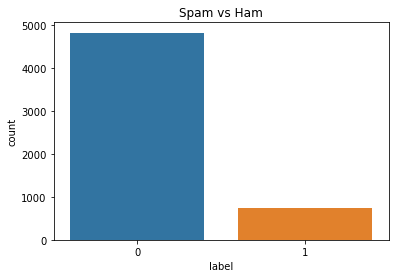

In [5]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

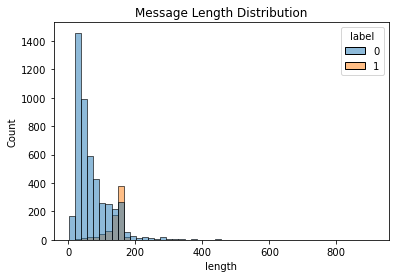

In [6]:
df['length'] = df['message'].apply(len)

sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Message Length Distribution")
plt.show()

In [5]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['cleaned']).toarray()
y = df['label']

In [ ]:
# AVI'S PART

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [9]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [10]:
def evaluate(y_test, y_pred):
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

In [11]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [
        evaluate(y_test, y_pred_nb)[0],
        evaluate(y_test, y_pred_lr)[0],
        evaluate(y_test, y_pred_svm)[0]
    ],
    'Precision': [
        evaluate(y_test, y_pred_nb)[1],
        evaluate(y_test, y_pred_lr)[1],
        evaluate(y_test, y_pred_svm)[1]
    ],
    'Recall': [
        evaluate(y_test, y_pred_nb)[2],
        evaluate(y_test, y_pred_lr)[2],
        evaluate(y_test, y_pred_svm)[2]
    ],
    'F1 Score': [
        evaluate(y_test, y_pred_nb)[3],
        evaluate(y_test, y_pred_lr)[3],
        evaluate(y_test, y_pred_svm)[3]
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.974888   1.000000  0.813333  0.897059
1  Logistic Regression  0.956951   0.963636  0.706667  0.815385
2                  SVM  0.976682   0.992063  0.833333  0.905797


In [ ]:
# SVM already initialized with probability=True above.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test)
y_prob_best = best_lr.predict_proba(X_test)[:, 1]

Best Params: {'C': 10, 'solver': 'liblinear'}


In [13]:
def evaluate_model(name, y_test, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

final_results = pd.DataFrame([
    evaluate_model("Naive Bayes", y_test, y_pred_nb),
    evaluate_model("Logistic Regression", y_test, y_pred_lr),
    evaluate_model("SVM", y_test, y_pred_svm),
    evaluate_model("Tuned Logistic Regression", y_test, y_pred_best)
])

print(final_results)

                       Model  Accuracy  Precision    Recall  F1 Score
0                Naive Bayes  0.974888   1.000000  0.813333  0.897059
1        Logistic Regression  0.956951   0.963636  0.706667  0.815385
2                        SVM  0.976682   0.992063  0.833333  0.905797
3  Tuned Logistic Regression  0.976682   0.976923  0.846667  0.907143


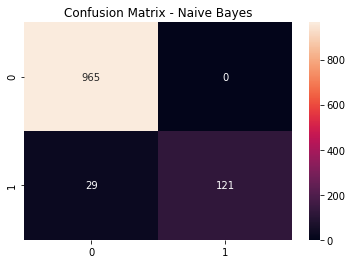

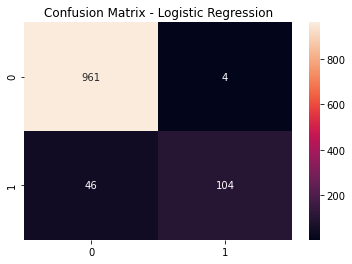

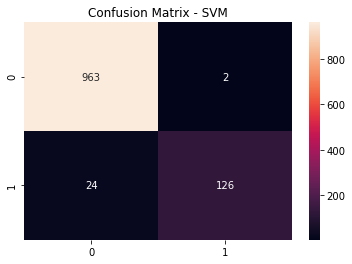

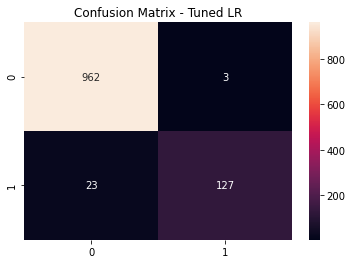

In [34]:
models_preds = {
    "Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Tuned LR": y_pred_best
}

for name, pred in models_preds.items():
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Logistic Regression does not support predict_proba properly
SVM does not support predict_proba properly


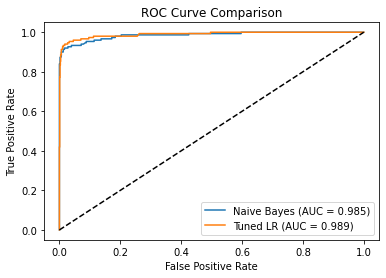

In [38]:
from sklearn.metrics import roc_curve, auc
models = [
    ("Naive Bayes", nb),
    ("Logistic Regression", lr),
    ("SVM", svm),
    ("Tuned LR", best_lr)
]
plt.figure()

for name, model in models:
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except:
        print(f"{name} does not support predict_proba properly")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

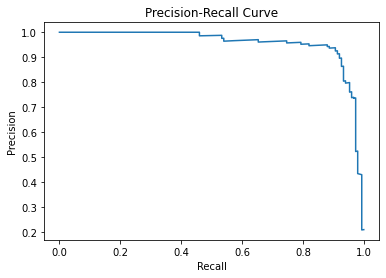

In [ ]:
from sklearn.metrics import precision_recall_curve

y_prob_lr = lr.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# HARSHIT 'S PART

In [45]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_results = []

models = [
    ("Naive Bayes", MultinomialNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("SVM", SVC(probability=True)),
    ("Tuned LR", best_lr)
]

for name, model in models:
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    
    cv_results.append({
        "Model": name,
        "CV Mean F1": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)

In [ ]:
cv_df.set_index("Model")["CV Mean F1"].plot(kind='bar')
plt.title("Cross-Validation F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure()

plt.bar(cv_df["Model"], cv_df["CV Mean F1"], yerr=cv_df["CV Std"])
plt.title("Cross-Validation Scores with Variability")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Grid search already run above to obtain best_lr.

Best Params: {'C': 10, 'solver': 'liblinear'}


In [19]:
y_prob_nb = nb.predict_proba(X_test)[:,1]
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]

In [20]:
from sklearn.metrics import roc_curve, auc

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

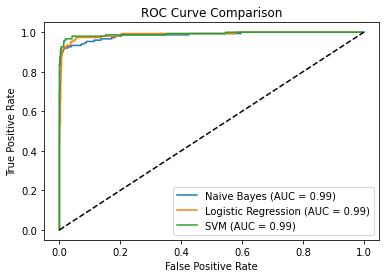

In [21]:
plt.figure()

plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# SARTHAK'S PART

In [27]:
def predict_spam(text):
    text = clean_text(text)
    vector = tfidf.transform([text]).toarray()
    return "Spam" if best_lr.predict(vector)[0] == 1 else "Ham"

In [15]:
def predict_spam(text):
    # Step 1: Clean text
    text = clean_text(text)
    
    # Step 2: Vectorize
    vector = tfidf.transform([text])
    
    # Step 3: Predict
    prediction = best_lr.predict(vector)[0]
    
    # Step 4: Probability (nice touch)
    prob = best_lr.predict_proba(vector)[0][1]
    
    if prediction == 1:
        return f"🚫 Spam (Confidence: {prob:.2f})"
    else:
        return f"✅ Ham (Not Spam) (Confidence: {1-prob:.2f})"

In [16]:
print(predict_spam("Congratulations! You won a free iPhone. Click now!"))
print(predict_spam("Hey, are we meeting tomorrow?"))

✅ Ham (Not Spam) (Confidence: 0.74)
✅ Ham (Not Spam) (Confidence: 1.00)


In [ ]:
while True:
    msg = input("\nEnter a message (or type 'exit'): ")
    
    if msg.lower() == 'exit':
        break
        
    result = predict_spam(msg)
    print(result)